In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

In [2]:
# going to do an investigation into the results


In [ ]:
# load in data: we're going to need the model results, experimental data, and parameter dataset.
ROOT = Path.cwd().parent.resolve()
DATA_DIR = ROOT / "data"
model_results = pd.read_csv(DATA_DIR / "results" / "_deterministic_wltp_results.csv")
exp_data = pd.read_csv(DATA_DIR / "processed" / "MLP001_wltp_25degC_record_deq.csv")
param_data = pd.read_csv(DATA_DIR / "processed" / "MLP001_params.csv")

In [4]:
#visualise the resolution of the model results soc values ie print the number of unique soc vals/
n_unique_soc_vals = model_results["soc"].nunique()
print(f"Number of unique soc values in model results: {n_unique_soc_vals}")

Number of unique soc values in model results: 121533


In [5]:
# for the parameter set we only want to work with the subset that is based on 25 degC data, so we will filter the parameter dataset to only include those rows.
param_data_25degC = param_data[param_data["Temperature_degC"] == 25.0]
unique_socs_params = param_data_25degC["SOC"].unique()

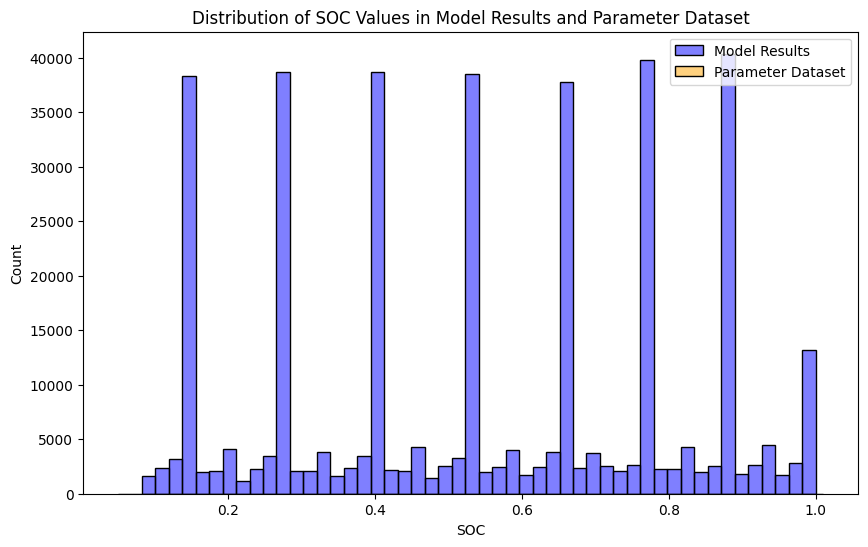

In [6]:
# see initially how many values there are in the simulation results corresponding to these unique soc values
results_at_param_socs = model_results[model_results["soc"].isin(unique_socs_params)]
n_results_at_param_socs = results_at_param_socs["soc"].nunique()
# plot the distribution of the soc values in the model results and the parameter dataset to see how they compare.
plt.figure(figsize=(10, 6))
sns.histplot(model_results["soc"], bins=50, color="blue", label="Model Results", alpha=0.5)
sns.histplot(unique_socs_params, bins=50, color="orange", label="Parameter Dataset", alpha=0.5)
plt.title("Distribution of SOC Values in Model Results and Parameter Dataset")
plt.xlabel("SOC")
plt.ylabel("Count")
plt.legend()
plt.show()

In [7]:
# you can clearly see the effect of steady states here; that's not what we're interested in for this point though.
# plot the distribution of the n_results_at_param_socs
print(f"Number of unique soc values in model results that are also in parameter dataset: {n_results_at_param_socs}")

Number of unique soc values in model results that are also in parameter dataset: 0


In [8]:
# this is not ideal; I was afraid that any difference in resolution would mean that they never hit exactly the same SOC values.
# another I'd like to do is to plot the correlation between the distance to a 'known' soc point and the error in v_cell at that point. This will be a good way to see if the errors are larger when the soc is further away from a known soc point. To do this, we will need to calculate the distance to the nearest known soc point for each soc value in the model results. We can then plot this distance against the error in v_cell at that point.
known_socs = unique_socs_params
known_socs
model_results["nearest_known_soc"] = model_results["soc"].apply(lambda x: min(known_socs, key=lambda y: abs(y - x)))
model_results["distance_to_nearest_known_soc"] = np.abs(model_results["soc"] - model_results["nearest_known_soc"])

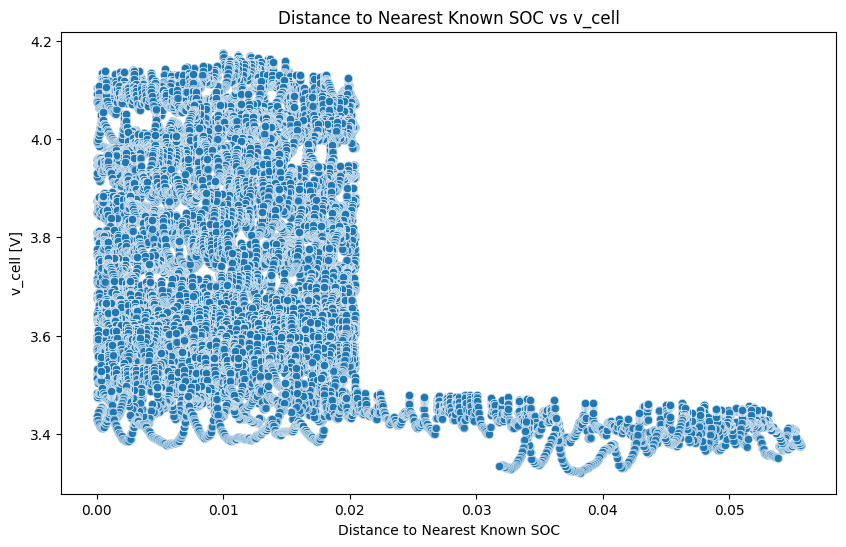

In [9]:
# plot this for sense checking
plt.figure(figsize=(10, 6))
sns.scatterplot(data=model_results, x="distance_to_nearest_known_soc", y="v_cell [V]", alpha=0.5)
plt.title("Distance to Nearest Known SOC vs v_cell")
plt.xlabel("Distance to Nearest Known SOC")
plt.ylabel("v_cell [V]")
plt.show()

In [10]:
# is there an error heading in the model results? I can't remember:
model_results.columns

Index(['t [s]', 'soc', 'v_oc [V]', 'v_rc1 [V]', 'v_rc2 [V]', 'v_cell [V]',
       'T [°C]', 'r0 [Ohm]', 'r1 [Ohm]', 'r2 [Ohm]', 'c1 [F]', 'c2 [F]',
       'I [A]', 'nearest_known_soc', 'distance_to_nearest_known_soc'],
      dtype='object')

In [11]:
# nope
exp_times_seconds, exp_voltages = exp_data["deq_Elapsed Time[h]"] * 3600, exp_data["Voltage(V)"]

# check to see how many times the time columns line up; we can do this by checking how many times the time values in the model results are present in the experimental data.
model_times_seconds = model_results["t [s]"].values
exp_times_seconds_set = set(exp_times_seconds.values)
matching_times = [t for t in model_times_seconds if t in exp_times_seconds_set]
print(f"Number of matching time values between model results and experimental data: {len(matching_times)}")
# nice, they all match up (which was intentional on my part, a good use of dequantisation.)

Number of matching time values between model results and experimental data: 364172


In [12]:
model_results["model_error"] = np.abs(model_results["v_cell [V]"] - exp_data["Voltage(V)"].values)

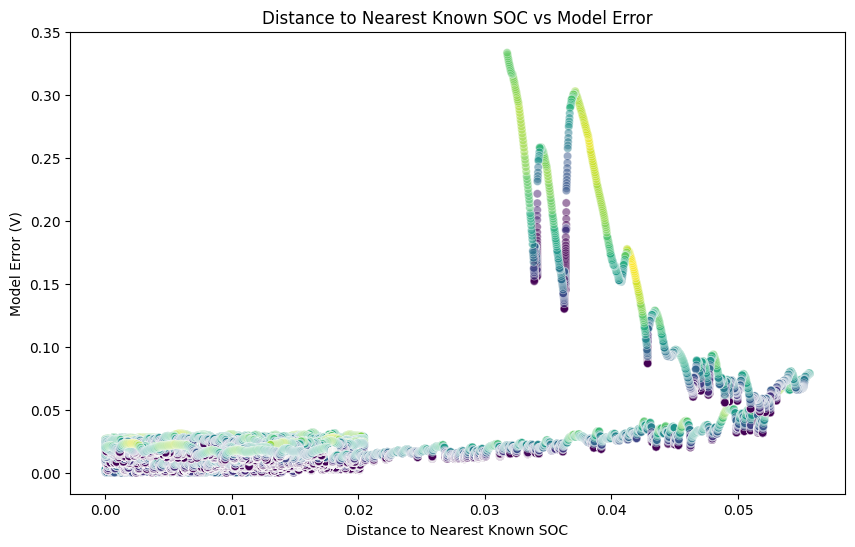

In [13]:
# model error against distance to nearest known soc.

plt.figure(figsize=(10, 6))
sns.scatterplot(data=model_results, x="distance_to_nearest_known_soc", y="model_error",c=model_results["I [A]"], alpha=0.5)
plt.title("Distance to Nearest Known SOC vs Model Error")
plt.xlabel("Distance to Nearest Known SOC")
plt.ylabel("Model Error (V)")
plt.show()

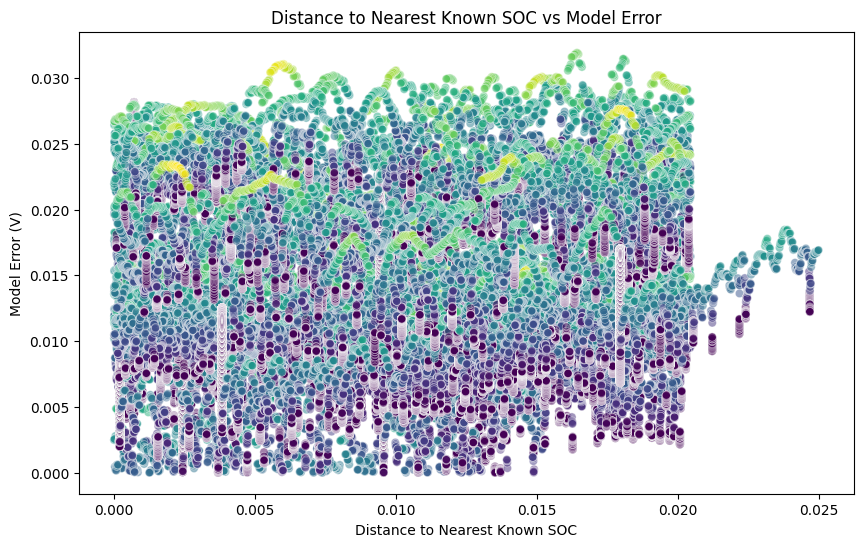

In [14]:
# we only care about ones that are up to ~ 0.025 points away from a known soc point, so we will filter the model results to only include those points.
filtered_model_results = model_results[model_results["distance_to_nearest_known_soc"] <= 0.025]

#plot again to make sure:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=filtered_model_results, x="distance_to_nearest_known_soc", y="model_error",c=filtered_model_results["I [A]"], alpha=0.5)
plt.title("Distance to Nearest Known SOC vs Model Error")
plt.xlabel("Distance to Nearest Known SOC")
plt.ylabel("Model Error (V)")
plt.show()

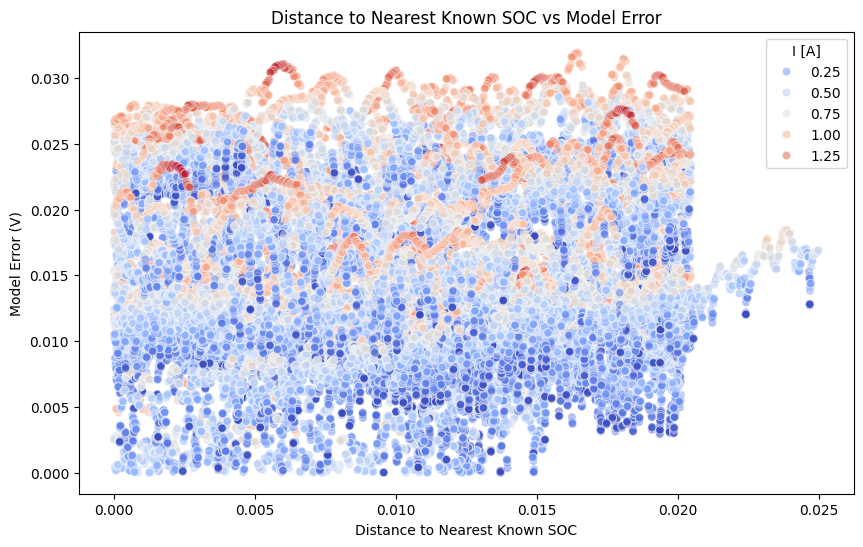

In [15]:
# not much of an obvious trend.
# how about we coarsely remove steady states. i.e. remove points where the current = 0, and we can see if there is a trend in the model error with respect to distance to nearest known soc point.
model_results_filters = filtered_model_results[filtered_model_results["I [A]"] != 0]
# plot again to make sure:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=model_results_filters, x="distance_to_nearest_known_soc", y="model_error",hue=model_results_filters["I [A]"], alpha=0.5, palette="coolwarm")
plt.title("Distance to Nearest Known SOC vs Model Error")
plt.xlabel("Distance to Nearest Known SOC")
plt.ylabel("Model Error (V)")
plt.show()

In [16]:
# can we quantify this? Let's try to calculate the correlation coefficient between the distance to nearest known soc and the model error.
correlation_coefficient = model_results_filters["distance_to_nearest_known_soc"].corr(model_results_filters["model_error"])
print(f"Correlation coefficient between distance to nearest known SOC and model error: {correlation_coefficient}")

# is this a statistically significant correlation? Let's calculate the p-value for this correlation coefficient.
from scipy.stats import pearsonr
corr_coef, p_value = pearsonr(model_results_filters["distance_to_nearest_known_soc"], model_results_filters["model_error"])
print(f"Pearson correlation coefficient: {corr_coef}, p-value: {p_value}, datapoints: {len(model_results_filters)}")
# is this statistically significant? Let's use a significance level of 0.05.
alpha = 0.05
if p_value < alpha:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")

# can we separate into different current amounts: this feels more promising.


Correlation coefficient between distance to nearest known SOC and model error: 0.01758104080349979
Pearson correlation coefficient: 0.017581040803499752, p-value: 9.146305846227161e-06, datapoints: 63669
The correlation is statistically significant.


Unique current values in model results filters: [0.0383344 0.0383468 0.0383846 ... 0.6375136 0.637574  0.6378385], unique current values count: 61405


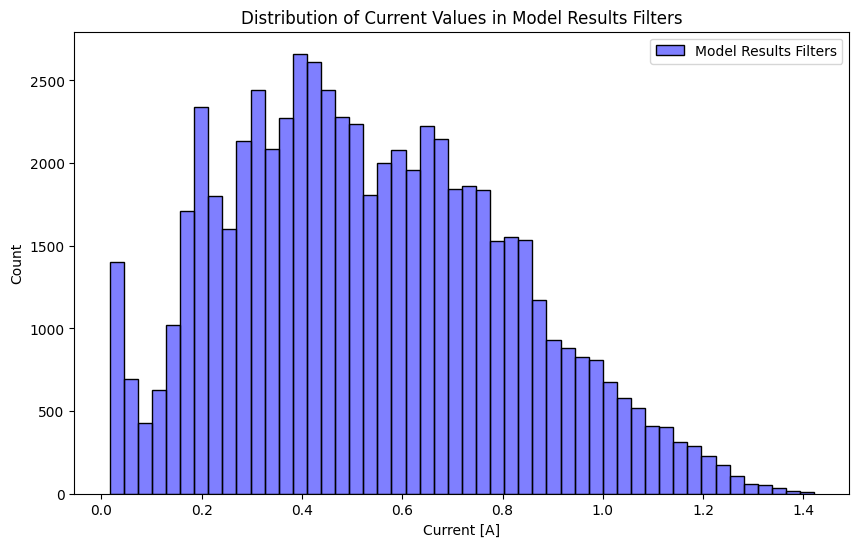

In [17]:
def get_p_cc(df, x_col, y_col):
    """
    Get the Pearson correlation coefficient and p-value for the correlation between two columns in a dataframe.
    """
    corr_coef, p_value = pearsonr(df[x_col], df[y_col])
    return corr_coef, p_value

# get the unique current values that are present in the model results filters dataframe, and then for each current value, we will calculate the Pearson correlation coefficient and p-value for the correlation between the distance to nearest known soc and the model error
#print all the unique current values for sense checking
print(f"Unique current values in model results filters: {model_results_filters['I [A]'].unique()}, unique current values count: {len(model_results_filters['I [A]'].unique())}")
# split currents up into wider bins to see if there is a trend in the corr. coefficient wrt current.
# first we will see the distribution of the current values in the model results filters dataframe.
plt.figure(figsize=(10, 6))
sns.histplot(model_results_filters["I [A]"], bins=50, color="blue", label="Model Results Filters", alpha=0.5)
plt.title("Distribution of Current Values in Model Results Filters")
plt.xlabel("Current [A]")
plt.ylabel("Count")
plt.legend()
plt.show()

In [18]:
# we will therefore split into bins of 0.1 A, and then for each bin we will calculate the Pearson correlation coefficient and p-value for the correlation between the distance to nearest known soc and the model error.
current_bins = np.arange(model_results_filters["I [A]"].min(), model_results_filters["I [A]"].max() + 0.1, 0.1)
model_results_filters = model_results_filters.copy()
model_results_filters["current_bin"] = pd.cut(model_results_filters["I [A]"], bins=current_bins)

#print the unique current bins for sense checking
print(f"Unique current bins in model results filters: {model_results_filters['current_bin'].unique()}, unique current bins count: {len(model_results_filters['current_bin'].unique())}")

Unique current bins in model results filters: [(0.0166, 0.117], (0.117, 0.217], (0.317, 0.417], (0.417, 0.517], (0.617, 0.717], ..., (1.017, 1.117], (1.117, 1.217], (1.217, 1.317], (1.317, 1.417], (1.417, 1.517]]
Length: 16
Categories (15, interval[float64, right]): [(0.0166, 0.117] < (0.117, 0.217] < (0.217, 0.317] < (0.317, 0.417] ... (1.117, 1.217] < (1.217, 1.317] < (1.317, 1.417] < (1.417, 1.517]], unique current bins count: 16


Current: (0.0166, 0.117], Pearson correlation coefficient: -0.044006784197829295, p-value: 0.02103342190527685, datapoints: 2749
Current: (0.117, 0.217], Pearson correlation coefficient: -0.027649082895172247, p-value: 0.03668682190530459, datapoints: 5710
Current: (0.317, 0.417], Pearson correlation coefficient: -0.0006434322890453201, p-value: 0.9531330033784582, datapoints: 8346
Current: (0.417, 0.517], Pearson correlation coefficient: 0.038575798774641484, p-value: 0.0003577540149822582, datapoints: 8558
Current: (0.617, 0.717], Pearson correlation coefficient: 0.028501525115623778, p-value: 0.014751736640599623, datapoints: 7319
Current: (0.217, 0.317], Pearson correlation coefficient: -0.006543088769535016, p-value: 0.5834728485728498, datapoints: 7025
Current: (0.517, 0.617], Pearson correlation coefficient: 0.052157504186555084, p-value: 1.3188991025718801e-05, datapoints: 6971
Current: nan, Not enough data points to calculate correlation.
Current: (0.717, 0.817], Pearson corre

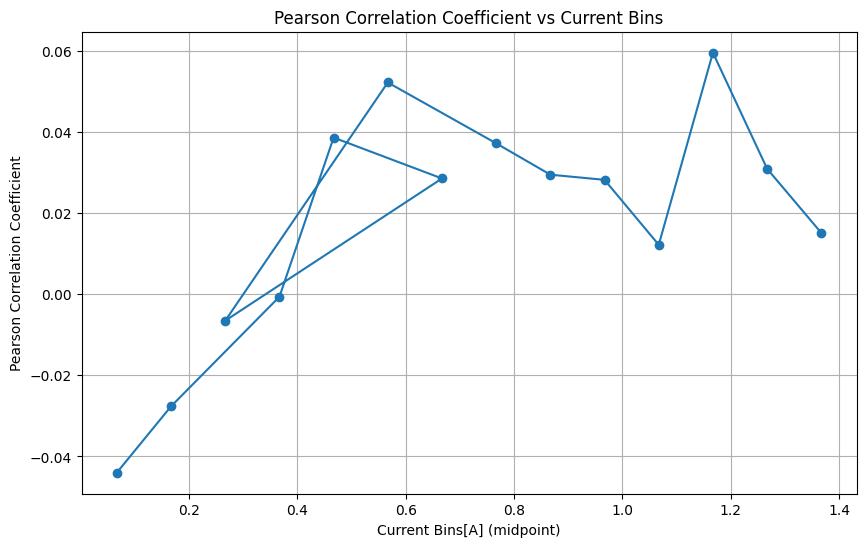

In [19]:
corr_coeffs = np.zeros_like(model_results_filters["current_bin"].unique(), dtype=float)
for index, current in enumerate(model_results_filters["current_bin"].unique()):  # Exclude the last bin which may be empty
    current_df = model_results_filters[model_results_filters["current_bin"] == current]
    if len(current_df) < 2:
        print(f"Current: {current}, Not enough data points to calculate correlation.")
        corr_coeffs[index] = np.nan  # Assign NaN for bins with insufficient data
        continue
    corr_coef, p_value = get_p_cc(current_df, "distance_to_nearest_known_soc", "model_error")
    corr_coeffs[index] = corr_coef
    print(f"Current: {current}, Pearson correlation coefficient: {corr_coef}, p-value: {p_value}, datapoints: {len(current_df)}")



# plot the correlation coefficients against the current bins to see if there is a trend.
# construct the arrays
bins_mids = []
corr_coeffs_plot = []
for corr_coef, current in zip(corr_coeffs[:-1], model_results_filters["current_bin"].unique()):
    if np.isnan(corr_coef):
        continue
    bins_mids.append(current.mid)
    corr_coeffs_plot.append(corr_coef)



plt.figure(figsize=(10, 6))
plt.plot(bins_mids, corr_coeffs_plot, marker='o') # take the midpoint for easy plotting.
plt.title("Pearson Correlation Coefficient vs Current Bins")
plt.xlabel("Current Bins[A] (midpoint)")
plt.ylabel("Pearson Correlation Coefficient")
plt.grid()
plt.show()


In [20]:
# no obvious correlation; we have to split up and remove transients.
# first, get the data again (as we are effectively starting over with a new approach)
model_results = pd.read_csv(DATA_DIR / "results" / "_deterministic_wltp_results.csv")
exp_data = pd.read_csv(DATA_DIR / "processed" / "MLP001_wltp_25degC_record_deq.csv")
param_data = pd.read_csv(DATA_DIR / "processed" / "MLP001_params.csv")

# filter out indices where the soc is very low, and apply this to the model results and exp data dfs, sp the indices match up.
mask = model_results["soc"] > 0.45
model_results = model_results[mask]
exp_data = exp_data[mask]

In [21]:
def group_into_stages(model_df, voltage_column, current_col, dvoltagedt_threshold=0.01, current_threshold=0.1, window_size=5):
    # get the gradient of the voltage at each point.
    model_df["Cycle Stage"] = "Unknown"
    model_df["voltage_gradient"] = np.gradient(model_df[voltage_column])
    model_df.loc[model_df[current_col] > current_threshold, "Cycle Stage"] = "Discharge"
    model_df.loc[model_df[current_col] < -current_threshold, "Cycle Stage"] = "Charge"
    model_df.loc[(model_df[current_col] <= current_threshold) & (model_df[current_col] >= -current_threshold) & (model_df["voltage_gradient"] < dvoltagedt_threshold), "Cycle Stage"] = "Rest"

    # if an unkown stage is present, we will assign it the modal value from a surrounding window of x points. 
    # This is to account for the fact that there may be a few points in the middle of a stage that are misclassified due to noise or other factors. 
    # We will use a window of 5 points on either side of the unknown point to determine the modal value.
    # unless ofc the modal value is also unknown, in which case we will take the next modal value


    def _assign_unkowns():
        unknown_indices = model_df[model_df["Cycle Stage"] == "Unknown"].index
        for idx in unknown_indices:
            window_start = max(0, idx - window_size)
            window_end = min(len(model_df), idx + window_size + 1)
            window_stages = model_df.loc[window_start:window_end, "Cycle Stage"]
            modal_stage = window_stages.mode()[0]  # get the most common stage in the window
            if modal_stage == "Unknown":
                # if the modal stage is unknown, we will take the next most common stage in the window
                modal_stage = window_stages.value_counts().index[1]
            model_df.at[idx, "Cycle Stage"] = modal_stage

    _assign_unkowns()

    return model_df


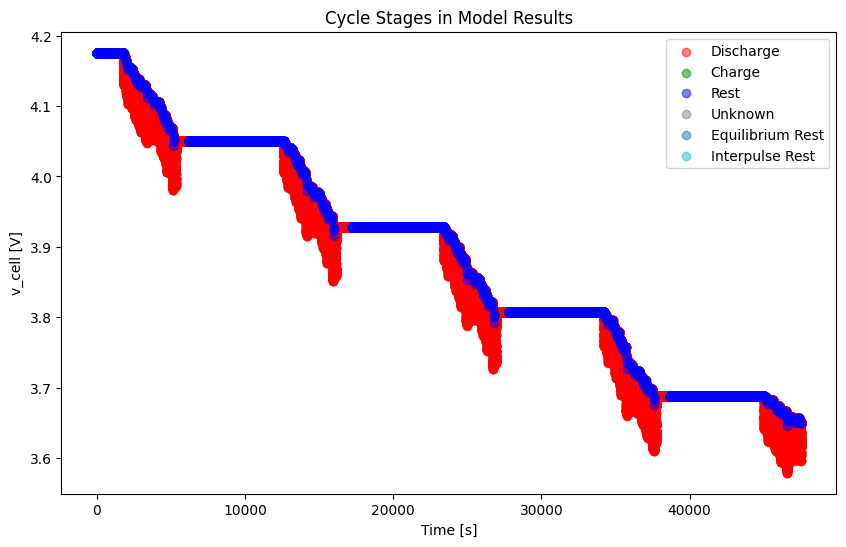

In [22]:
grouped_df = group_into_stages(model_results.copy(), "v_cell [V]", "I [A]", dvoltagedt_threshold=0.000000000000001, current_threshold=0.00000000000001, window_size=50)

def plot_stages(grouped_df, cycle_stage_col="Cycle Stage"):
    colours = {"Discharge": "red", "Charge": "green", "Rest": "blue", "Unknown": "grey","Equilibrium Rest": "tab:blue", "Interpulse Rest": "tab:cyan"}
    plt.figure(figsize=(10, 6))
    for stage, colour in colours.items():
        stage_df = grouped_df[grouped_df[cycle_stage_col] == stage]
        plt.scatter(stage_df["t [s]"], stage_df["v_cell [V]"], color=colour, label=stage, alpha=0.5)
    plt.title("Cycle Stages in Model Results")
    plt.xlabel("Time [s]")
    plt.ylabel("v_cell [V]")
    plt.legend()
    plt.show()

plot_stages(grouped_df)

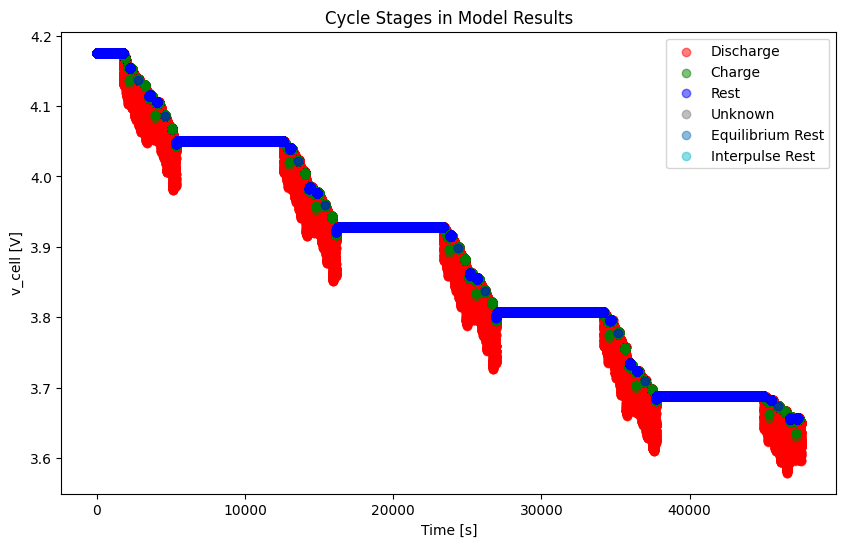

In [23]:
# this in't working too well;
 # lets try smoothing the voltage signal first, and then calculating the gradient of the smoothed signal. This should help to reduce the noise in the gradient calculation and improve the classification of the cycle stages.

from scipy.signal import savgol_filter
model_results1 = model_results.copy()
med_current = model_results1["I [A]"].median()
med_voltage = model_results1["v_cell [V]"].median()

model_results1["voltage_smooth"] = savgol_filter(model_results1["v_cell [V]"], window_length=300, polyorder=2)
model_results1["current_smooth"] = savgol_filter(model_results1["I [A]"], window_length=300, polyorder=2)
model_results1["voltage_gradient"] = np.gradient(model_results1["voltage_smooth"])

group_into_stages(model_results1, "voltage_smooth", "current_smooth", dvoltagedt_threshold=0.01*med_voltage, current_threshold=0.01*med_current, window_size=50)


plot_stages(model_results1)



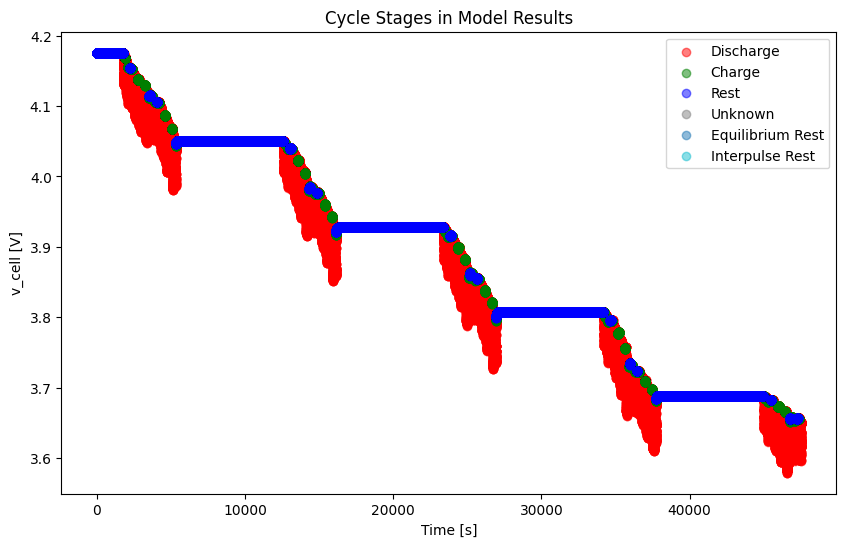

In [24]:
def debounce_stages(stage_series, min_run=20):
    stages = stage_series.to_numpy()
    n = len(stages)
    # find run boundaries
    change_points = np.where(stages[1:] != stages[:-1])[0] + 1
    run_starts = np.concatenate(([0], change_points))
    run_ends = np.concatenate((change_points, [n]))

    for i in range(len(run_starts)):
        start, end = run_starts[i], run_ends[i]
        if (end - start) < min_run:
            # merge into previous run (or next, if this is the first run)
            replacement = stages[run_starts[i - 1]] if i > 0 else stages[run_ends[i]]
            stages[start:end] = replacement

    return stages

model_results1["Debounced Stage"] = debounce_stages(model_results1["Cycle Stage"], min_run=20)
plot_stages(model_results1, cycle_stage_col="Debounced Stage")

In [35]:
def print_stages(model_df, stage_col="Cycle Stage", highlight_stage=None):
    """print the stages and their length one by by one, for sense checking"""
    stages = model_df[stage_col].to_numpy()
    n = len(stages)
    # find run boundaries
    change_points = np.where(stages[1:] != stages[:-1])[0] + 1
    run_starts = np.concatenate(([0], change_points))
    run_ends = np.concatenate((change_points, [n]))

    for i in range(len(run_starts)):
        start, end = run_starts[i], run_ends[i]
        if highlight_stage and stages[start] == highlight_stage:
            print(f"STAGE: {stages[start]}, LENGTH: {end - start}")
        elif not highlight_stage:
            print(f"Stage: {stages[start]}, Length: {end - start}")

print_stages(model_results1)

Stage: Rest, Length: 8912
Stage: Charge, Length: 81
Stage: Discharge, Length: 484
Stage: Charge, Length: 133
Stage: Discharge, Length: 940
Stage: Charge, Length: 53
Stage: Discharge, Length: 646
Stage: Charge, Length: 52
Stage: Rest, Length: 111
Stage: Charge, Length: 52
Stage: Discharge, Length: 413
Stage: Charge, Length: 55
Stage: Discharge, Length: 1997
Stage: Charge, Length: 137
Stage: Discharge, Length: 2197
Stage: Charge, Length: 83
Stage: Discharge, Length: 1360
Stage: Charge, Length: 75
Stage: Rest, Length: 131
Stage: Charge, Length: 81
Stage: Discharge, Length: 484
Stage: Charge, Length: 133
Stage: Discharge, Length: 940
Stage: Charge, Length: 53
Stage: Discharge, Length: 646
Stage: Charge, Length: 52
Stage: Rest, Length: 111
Stage: Charge, Length: 52
Stage: Discharge, Length: 413
Stage: Charge, Length: 55
Stage: Discharge, Length: 1997
Stage: Charge, Length: 137
Stage: Discharge, Length: 2197
Stage: Charge, Length: 83
Stage: Discharge, Length: 1360
Stage: Charge, Length: 75
S

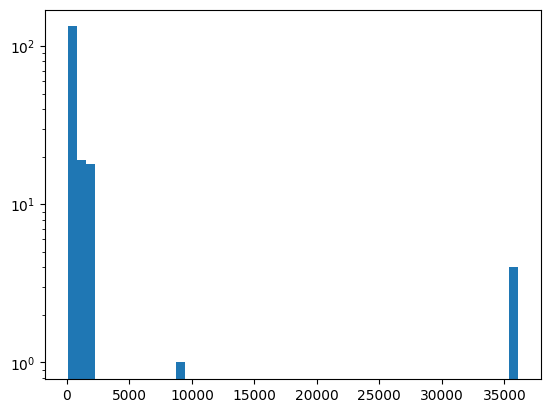

In [26]:
# plot distribution of lengths
def get_run_lengths(stages):
    stages = np.asarray(stages)
    change_points = np.where(stages[1:] != stages[:-1])[0] + 1
    run_starts = np.concatenate(([0], change_points))
    run_ends = np.concatenate((change_points, [len(stages)]))
    run_stage = stages[run_starts]
    run_len = run_ends - run_starts
    return run_stage, run_len

run_stage, run_len = get_run_lengths(model_results1["Cycle Stage"])
import matplotlib.pyplot as plt
plt.hist(run_len, bins=50)
plt.yscale("log")

Filtered Stage
Rest         195640
Discharge     42017
Name: count, dtype: int64


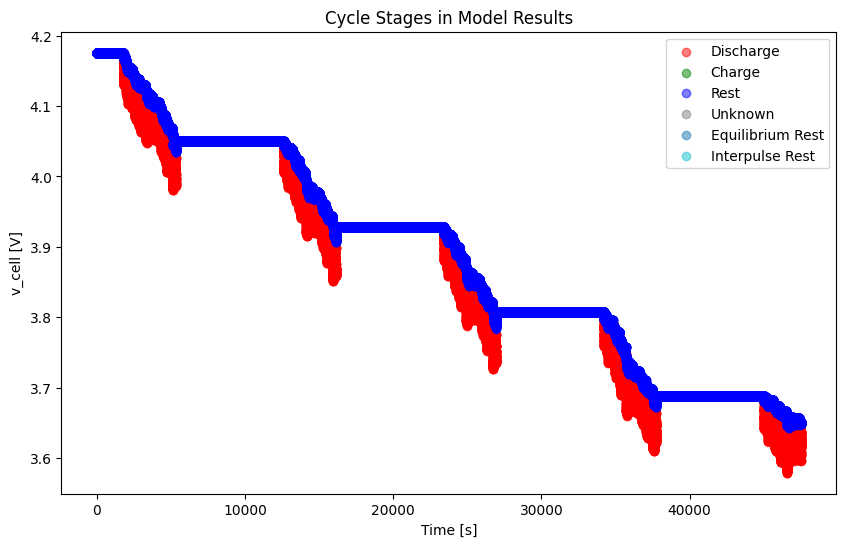

In [27]:
# the 35000 ones are the rest stages, the 8000 are some of the charge stages, the ones close to zero are erroneous.
# going to try and remove the erroneous ones.
# use schmitt triggering.

current_threshold_high = 0.001
current_threshold_low = 0.0005

def filter_trans_schmitt(model_df, current_col="I [A]", high_threshold=current_threshold_high, low_threshold=current_threshold_low):
    model_df = model_df.copy()
    model_df["Filtered Stage"] = "Unknown"
    above_high = model_df[current_col] > high_threshold
    below_low = model_df[current_col] < low_threshold

    # Initialize the state
    state = "Discharge"

    for i in range(len(model_df)):
        if above_high[i]:
            state = "Discharge"
        elif below_low[i]:
            state = "Rest"
        # Assign the current state to the Filtered Stage column
        model_df.at[i, "Filtered Stage"] = state

    return model_df
model_results_schmitt = filter_trans_schmitt(model_results, current_col="I [A]", high_threshold=current_threshold_high, low_threshold=current_threshold_low)
print(model_results_schmitt["Filtered Stage"].value_counts())
plot_stages(model_results_schmitt, cycle_stage_col="Filtered Stage")

In [28]:
# the same problem presists; need a better way of setting these thresholds.
# will look at the noise in a known rest segment to see what the noise looks like, and then set the thresholds based on that.
known_rest_itv = (0,8500) # in timesteps (0.25 seconds each.)
known_rest_data = model_results1.iloc[known_rest_itv[0]:known_rest_itv[1]]
noise_std = known_rest_data["I [A]"].std()
print(f"Standard deviation of current in known rest segment: {noise_std}")
noise_mean = known_rest_data["I [A]"].mean()
print(f"Mean of current in known rest segment: {noise_mean}")

# no noise in the rest segment... further investigation required (yay)
print(model_results_schmitt.columns)

Standard deviation of current in known rest segment: 0.0
Mean of current in known rest segment: 0.0
Index(['t [s]', 'soc', 'v_oc [V]', 'v_rc1 [V]', 'v_rc2 [V]', 'v_cell [V]',
       'T [°C]', 'r0 [Ohm]', 'r1 [Ohm]', 'r2 [Ohm]', 'c1 [F]', 'c2 [F]',
       'I [A]', 'Filtered Stage'],
      dtype='object')


In [29]:
run_stage, run_len = get_run_lengths(model_results_schmitt["Filtered Stage"].to_numpy())
run_starts = np.concatenate(([0], np.cumsum(run_len)[:-1]))
# find short runs, their start and ends.
short_runs = [(s, s+l, stage) for s, l, stage in zip(run_starts, run_len, run_stage) if l < 100]

for s, e, stage in short_runs[:5]:
    print(stage, model_results_schmitt.loc[s:e, ["t [s]", "I [A]", "v_oc [V]"]])

Rest        t [s]     I [A]  v_oc [V]
9177  1835.2 -0.000000  4.172256
9178  1835.4 -0.000000  4.172252
9179  1835.6 -0.000000  4.172250
9180  1835.8 -0.000000  4.172250
9181  1836.0 -0.000000  4.172251
...      ...       ...       ...
9243  1848.4 -0.000000  4.172254
9244  1848.6 -0.000000  4.172254
9245  1848.8 -0.000000  4.172254
9246  1849.0 -0.000000  4.172253
9247  1849.2  0.028778  4.172252

[71 rows x 3 columns]
Discharge        t [s]     I [A]  v_oc [V]
9247  1849.2  0.028778  4.172252
9248  1849.4  0.028908  4.172251
9249  1849.6  0.028806  4.172250
9250  1849.8  0.028821  4.172248
9251  1850.0  0.028826  4.172247
9252  1850.2 -0.000000  4.172247
Rest        t [s]     I [A]  v_oc [V]
9252  1850.2 -0.000000  4.172247
9253  1850.4 -0.000000  4.172246
9254  1850.6 -0.000000  4.172246
9255  1850.8 -0.000000  4.172246
9256  1851.0 -0.000000  4.172246
9257  1851.2 -0.000000  4.172246
9258  1851.4 -0.000000  4.172246
9259  1851.6 -0.000000  4.172246
9260  1851.8 -0.000000  4.172246


Filtered Stage
Equilibrium Rest    154790
Discharge            42017
Interpulse Rest      40850
Name: count, dtype: int64


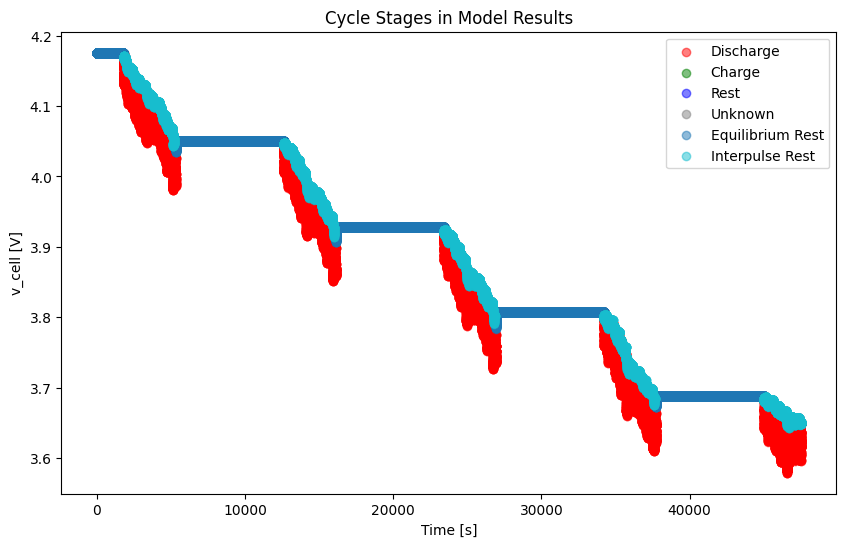

In [30]:
def get_per_point_run_length(stage_series):
    stages = stage_series.to_numpy()
    n = len(stages)
    change_points = np.where(stages[1:] != stages[:-1])[0] + 1
    run_starts = np.concatenate(([0], change_points))
    run_ends = np.concatenate((change_points, [n]))
    run_lengths = run_ends - run_starts

    per_point_len = np.empty(n, dtype=int)
    for start, end, length in zip(run_starts, run_ends, run_lengths):
        per_point_len[start:end] = length
    return per_point_len

model_results_schmitt["run_length"] = get_per_point_run_length(model_results_schmitt["Filtered Stage"])

rest_mask = model_results_schmitt["Filtered Stage"] == "Rest"
model_results_schmitt.loc[rest_mask, "Filtered Stage"] = np.where(
    model_results_schmitt.loc[rest_mask, "run_length"] < 8000, "Interpulse Rest", "Equilibrium Rest"
)
print(model_results_schmitt["Filtered Stage"].value_counts())
plot_stages(model_results_schmitt, cycle_stage_col="Filtered Stage")


In [36]:
# print how many equilibrium rest stage runs there are
point_equilibrium_rest_runs = (model_results_schmitt["Filtered Stage"] == "Equilibrium Rest").sum()

# print every run and its length for sense checking
print_stages(model_results_schmitt, stage_col="Filtered Stage", highlight_stage="Equilibrium Rest")

STAGE: Equilibrium Rest, LENGTH: 9062
STAGE: Equilibrium Rest, LENGTH: 36432
STAGE: Equilibrium Rest, LENGTH: 36432
STAGE: Equilibrium Rest, LENGTH: 36432
STAGE: Equilibrium Rest, LENGTH: 36432


In [ ]:
# these are all correctly categorised now!
# will start a new notebook, with this new method exclusively as all the above methods will confuse me if I stay here.